# MCO2 Numerical Data Analysis Notebook

## Variables and Areas for Exploration
Independent Variables (What we control): Keyboard Size, Task Type
Dependent Variables: NASA-TLX scores. Typing Performance. 

We can explore relationship between...
- Keyboard Size and NASA-TLX Scores
- Task Type and NASA-TLX Score.
- Keyboard Size and Typing Performance.
- Task Type and Typing Performance.
- Keyboard Size + Task Type versus NASA-TLX.
- Keyboard Size + Task Type versus Typing Performance. 
- Correlate KB Size + Task Type versus NASA-TLX and versus Typing Performance.

## Setup

Import dependencies

In [18]:
# %pip install "numpy<2.0"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_theme(style="whitegrid", context="notebook")


Load CSVs

In [4]:
typing_test_df = pd.read_csv('typing_test_data.csv')
nasa_tlx_df = pd.read_csv('nasa_tlx.csv')

## Exploratory Data Analysis

### Exploring `typing_test_data.csv`

In [5]:
typing_test_df

,Participant Number,GroupNumber,Text_60_WPM,Text_60_Accuracy,Text_60_ErrorRate,Text_60_MouseTime,Text_60_Clicks,Text_60_Backspaces,Text_60_Scrolls,Text_60_TotalTime,...,Prog_100_Accuracy,Prog_100_ErrorRate,Prog_100_MouseTime,Prog_100_Clicks,Prog_100_Backspaces,Prog_100_Scrolls,Prog_100_TotalTime,Prog_100_CorrectChars,Prog_100_IncorrectFixed,Prog_100_IncorrectNotFixed
0,2,2,89.0,92.4,7.6,0.045,0,25,0,40.982,...,83.5,16.8,2.184,1,66,4,113.118,327,66,0
1,3,3,73.7,84.9,15.1,0.000,0,54,0,49.531,...,85.4,14.2,0.000,0,54,0,64.878,327,54,0
2,4,4,61.7,89.6,10.4,0.000,0,40,0,67.079,...,94.3,6.0,0.000,0,18,0,67.785,281,18,0
3,5,5,68.8,93.5,6.5,0.000,0,24,0,60.183,...,90.9,9.1,0.000,0,28,0,102.489,281,28,0
4,12,6,53.1,93.8,6.2,0.000,0,23,0,77.976,...,66.9,12.0,0.000,0,29,0,120.000,213,29,0
5,11,5,57.1,95.6,4.4,0.000,0,16,0,72.495,...,56.4,10.6,0.000,0,26,0,120.000,244,26,3
6,7,1,82.0,92.7,7.3,0.000,0,24,0,44.502,...,89.3,10.7,0.000,0,39,0,66.300,327,39,0
7,8,2,66.9,90.4,9.0,0.000,0,30,0,54.191,...,89.7,9.2,0.000,0,33,0,94.726,327,33,0
8,9,3,70.1,94.7,5.3,3.009,1,17,0,52.004,...,89.1,10.9,0.000,0,40,0,91.309,327,40,0
9,13,1,55.2,94.7,5.3,0.000,0,17,0,66.053,...,85.4,14.6,0.000,0,56,0,112.535,327,56,0


In [23]:
typing_test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 68 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Participant Number          33 non-null     int64  
 1   GroupNumber                 33 non-null     int64  
 2   Text_60_WPM                 33 non-null     float64
 3   Text_60_Accuracy            33 non-null     float64
 4   Text_60_ErrorRate           33 non-null     float64
 5   Text_60_MouseTime           33 non-null     float64
 6   Text_60_Clicks              33 non-null     int64  
 7   Text_60_Backspaces          33 non-null     int64  
 8   Text_60_Scrolls             33 non-null     int64  
 9   Text_60_TotalTime           33 non-null     float64
 10  Text_60_CorrectChars        33 non-null     int64  
 11  Text_60_IncorrectFixed      33 non-null     int64  
 12  Text_60_IncorrectNotFixed   33 non-null     int64  
 13  Num_60_WPM                  33 non-nu

In [6]:
typing_test_df.describe()

,Participant Number,GroupNumber,Text_60_WPM,Text_60_Accuracy,Text_60_ErrorRate,Text_60_MouseTime,Text_60_Clicks,Text_60_Backspaces,Text_60_Scrolls,Text_60_TotalTime,...,Prog_100_Accuracy,Prog_100_ErrorRate,Prog_100_MouseTime,Prog_100_Clicks,Prog_100_Backspaces,Prog_100_Scrolls,Prog_100_TotalTime,Prog_100_CorrectChars,Prog_100_IncorrectFixed,Prog_100_IncorrectNotFixed
count,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.0,33.000000,...,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000
mean,17.242424,3.333333,69.278788,92.275758,7.800000,0.519636,0.272727,27.363636,0.0,60.855515,...,86.800000,11.339394,0.448848,0.484848,37.878788,0.121212,97.962848,292.030303,37.878788,0.333333
std,10.059294,1.670828,18.638162,3.520035,3.959561,2.157308,1.097518,14.039716,0.0,19.694996,...,7.954676,4.305588,1.675085,1.954501,16.661628,0.696311,20.362716,32.043413,16.661628,0.853913
min,1.000000,1.000000,34.200000,82.600000,3.600000,0.000000,0.000000,12.000000,0.0,34.316000,...,56.400000,3.400000,0.000000,0.000000,10.000000,0.000000,63.357000,213.000000,10.000000,0.000000
25%,9.000000,2.000000,56.500000,90.400000,5.000000,0.000000,0.000000,17.000000,0.0,49.666000,...,84.500000,9.100000,0.000000,0.000000,26.000000,0.000000,79.323000,281.000000,26.000000,0.000000
50%,17.000000,3.000000,69.800000,93.500000,6.500000,0.000000,0.000000,24.000000,0.0,57.928000,...,88.100000,10.900000,0.000000,0.000000,35.000000,0.000000,103.653000,281.000000,35.000000,0.000000
75%,25.000000,5.000000,82.000000,95.000000,9.300000,0.000000,0.000000,32.000000,0.0,68.168000,...,90.900000,14.200000,0.000000,0.000000,52.000000,0.000000,120.000000,327.000000,52.000000,0.000000
max,35.000000,6.000000,106.000000,96.400000,21.700000,12.020000,6.000000,70.000000,0.0,120.000000,...,96.600000,22.400000,9.251000,11.000000,70.000000,4.000000,120.000000,327.000000,70.000000,3.000000


### Exploring `nasa_tlx.csv`

#### Typing test dataset: structural overview


In [7]:
typing_structure = (
    pd.DataFrame({
        "dtype": typing_test_df.dtypes,
        "unique": typing_test_df.nunique(),
        "missing": typing_test_df.isna().sum(),
    })
    .sort_values("unique", ascending=False)
)
typing_structure.head(10)


,dtype,unique,missing
Participant Number,int64,33,0
Text_60_TotalTime,float64,33,0
Num_100_WPM,float64,33,0
Text_100_TotalTime,float64,33,0
Text_100_WPM,float64,33,0
Num_60_WPM,float64,33,0
Prog_100_WPM,float64,32,0
Prog_60_WPM,float64,32,0
Text_60_WPM,float64,32,0
Prog_100_Accuracy,float64,31,0


#### Typing test dataset: key performance metrics


In [8]:
wpm_cols = [
    "Text_60_WPM",
    "Num_60_WPM",
    "Prog_60_WPM",
    "Text_100_WPM",
    "Num_100_WPM",
    "Prog_100_WPM",
]
accuracy_cols = [
    "Text_60_Accuracy",
    "Num_60_Accuracy",
    "Prog_60_Accuracy",
    "Text_100_Accuracy",
    "Num_100_Accuracy",
    "Prog_100_Accuracy",
]
key_metrics = (
    typing_test_df[wpm_cols + accuracy_cols]
    .agg(["mean", "std", "min", "max"])
    .T.round(2)
)
key_metrics


,mean,std,min,max
Text_60_WPM,69.28,18.64,34.2,106.0
Num_60_WPM,29.19,8.99,8.9,46.6
Prog_60_WPM,38.38,12.65,3.9,59.3
Text_100_WPM,70.31,19.48,32.2,101.0
Num_100_WPM,29.54,7.74,16.3,45.3
Prog_100_WPM,37.38,11.93,15.4,61.9
Text_60_Accuracy,92.28,3.52,82.6,96.4
Num_60_Accuracy,85.94,10.08,37.7,95.1
Prog_60_Accuracy,87.87,13.73,14.9,97.6
Text_100_Accuracy,90.99,4.69,81.6,98.1


#### Typing test dataset: group-level WPM comparison


In [9]:
group_wpm_summary = (
    typing_test_df.groupby("GroupNumber")[wpm_cols]
    .agg(["mean", "std"])
    .round(2)
)
group_wpm_summary


Text_60_WPM        Num_60_WPM        Prog_60_WPM         \
                   mean    std       mean    std        mean    std   
GroupNumber                                                           
1                 65.67  24.41      25.15  12.71       38.10  20.92   
2                 70.98  20.58      26.48   8.01       36.10   8.53   
3                 75.86  26.57      35.68  11.74       41.46  13.51   
4                 67.40   8.88      29.84   3.90       38.79   8.43   
5                 72.16  10.28      31.14   7.46       42.70  11.68   
6                 63.60  24.44      27.62   8.38       32.22  13.48   

            Text_100_WPM        Num_100_WPM        Prog_100_WPM         
                    mean    std        mean    std         mean    std  
GroupNumber                                                             
1                  66.38  20.16       32.57  10.23        43.95  14.97  
2                  64.40  21.44       27.47   7.55        35.07   9.55  
3                  71.72  24.72       34.68  11.20        44.72  13.38  
4                  75.69  17.95       27.13   5.55        36.41   7.95  
5                  76.54  16.65       29.42   2.92        33.64  11.96  
6                  66.08  22.68       26.08   5.45        28.22  10.63

#### Typing test dataset: WPM distributions


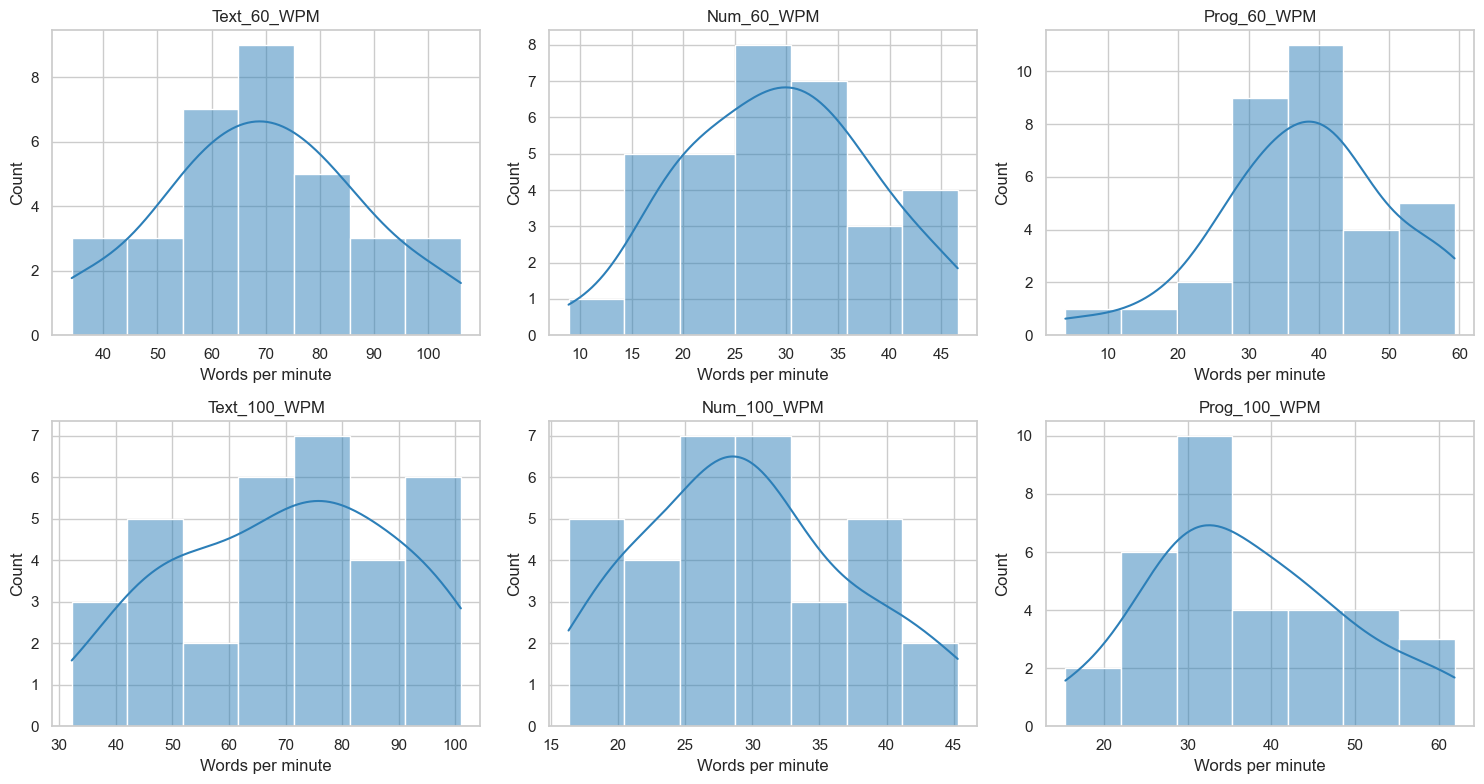

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)
for col, ax in zip(wpm_cols, axes.ravel()):
    sns.histplot(typing_test_df[col], kde=True, ax=ax, color="#2c7fb8")
    ax.set_title(col)
    ax.set_xlabel("Words per minute")
plt.tight_layout()


#### Typing test dataset: correlation between WPM and accuracy


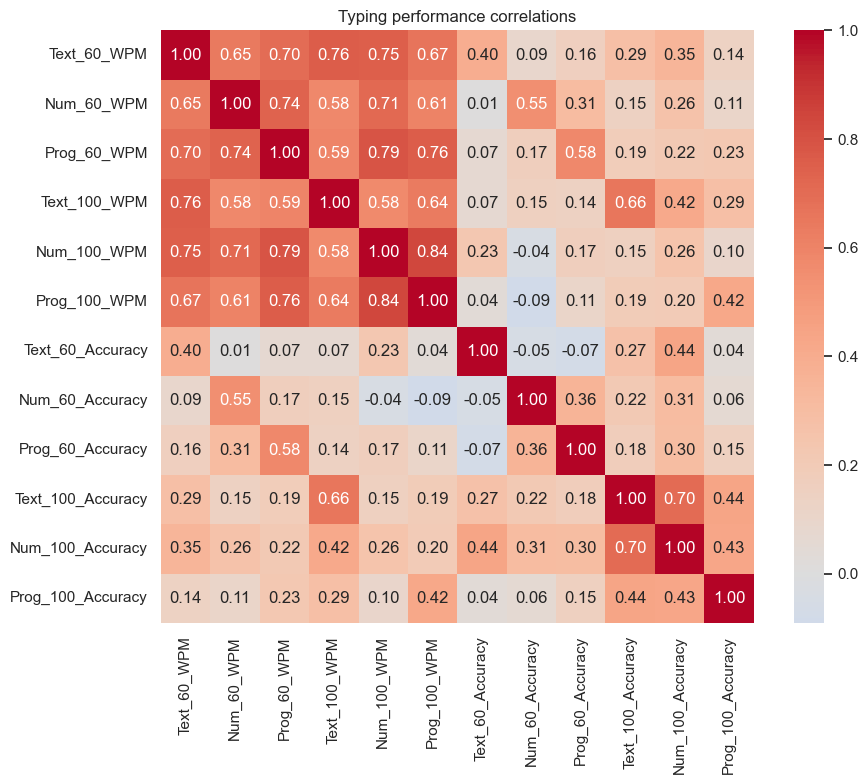

In [11]:
corr_cols = wpm_cols + accuracy_cols
corr_matrix = typing_test_df[corr_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=True, fmt=".2f", square=True)
plt.title("Typing performance correlations")
plt.tight_layout()


In [30]:
nasa_tlx_df

,Participant Number,Original Keyboard,Keyboard Type,Task Type,Mental Demand,Physical Demand,Temporal Demand,Performance,Effort,Frustration Level
0,15,Both,1,A,1,1,1,10,1,1
1,15,Both,1,B,7,8,4,5,5,2
2,15,Both,1,C,3,6,1,5,4,2
3,15,Both,2,A,1,1,1,7,1,1
4,15,Both,2,B,6,9,3,5,6,2
...,...,...,...,...,...,...,...,...,...,...
193,10,60,1,B,6,5,6,4,6,5
194,10,60,1,C,5,4,5,5,5,5
195,10,60,2,A,3,4,4,6,4,2
196,10,60,2,B,8,4,6,4,6,5


In [12]:
nasa_tlx_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Participant Number  198 non-null    int64 
 1   Original Keyboard   198 non-null    object
 2   Keyboard Type       198 non-null    int64 
 3   Task Type           198 non-null    object
 4   Mental Demand       198 non-null    int64 
 5   Physical Demand     198 non-null    int64 
 6   Temporal Demand     198 non-null    int64 
 7   Performance         198 non-null    int64 
 8   Effort              198 non-null    int64 
 9   Frustration Level   198 non-null    int64 
dtypes: int64(8), object(2)
memory usage: 15.6+ KB


In [13]:
nasa_tlx_df.describe()

,Participant Number,Keyboard Type,Mental Demand,Physical Demand,Temporal Demand,Performance,Effort,Frustration Level
count,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000
mean,17.242424,1.500000,4.318182,3.969697,4.176768,6.853535,4.444444,3.323232
std,9.930817,0.501267,2.092960,2.165510,2.406435,2.235787,2.283119,2.307913
min,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000
25%,9.000000,1.000000,3.000000,2.000000,2.000000,5.000000,3.000000,2.000000
50%,17.000000,1.500000,4.000000,4.000000,4.000000,7.000000,4.000000,2.000000
75%,25.000000,2.000000,6.000000,6.000000,6.000000,9.000000,6.000000,4.000000
max,35.000000,2.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


#### NASA TLX dataset: categorical overview


In [14]:
category_counts = {
    "Keyboard Type": nasa_tlx_df["Keyboard Type"].value_counts().sort_index(),
    "Task Type": nasa_tlx_df["Task Type"].value_counts().sort_index(),
    "Original Keyboard": nasa_tlx_df["Original Keyboard"].value_counts().sort_values(ascending=False).head(5),
}
for label, series in category_counts.items():
    display(pd.DataFrame(series).rename(columns={series.name: "count"}))


,count
Keyboard Type,
1,99
2,99


,count
Task Type,
A,66
B,66
C,66


,count
Original Keyboard,
100,66
60,48
Laptop,24
75,24
Both,6


#### NASA TLX dataset: workload scores by keyboard and task


In [15]:
workload_cols = [
    "Mental Demand",
    "Physical Demand",
    "Temporal Demand",
    "Performance",
    "Effort",
    "Frustration Level",
]
keyboard_summary = nasa_tlx_df.groupby("Keyboard Type")[workload_cols].mean().round(2)
task_summary = nasa_tlx_df.groupby("Task Type")[workload_cols].mean().round(2)
keyboard_summary, task_summary


(               Mental Demand  Physical Demand  Temporal Demand  Performance  \
 Keyboard Type                                                                 
 1                       4.47             4.07             4.18         6.81   
 2                       4.16             3.87             4.17         6.90   
 
                Effort  Frustration Level  
 Keyboard Type                             
 1                4.64               3.39  
 2                4.25               3.25  ,
            Mental Demand  Physical Demand  Temporal Demand  Performance  \
 Task Type                                                                 
 A                   3.21             3.05             3.23         7.88   
 B                   5.62             4.83             5.36         5.61   
 C                   4.12             4.03             3.94         7.08   
 
            Effort  Frustration Level  
 Task Type                             
 A            3.42               2.30  

#### NASA TLX dataset: workload distributions


/var/folders/dw/q54kxq493rqfpjbc9zk4mgv00000gn/T/ipykernel_16672/2455204164.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=nasa_tlx_df, x="Task Type", y="Mental Demand", ax=axes[0], palette="Set2")
/var/folders/dw/q54kxq493rqfpjbc9zk4mgv00000gn/T/ipykernel_16672/2455204164.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


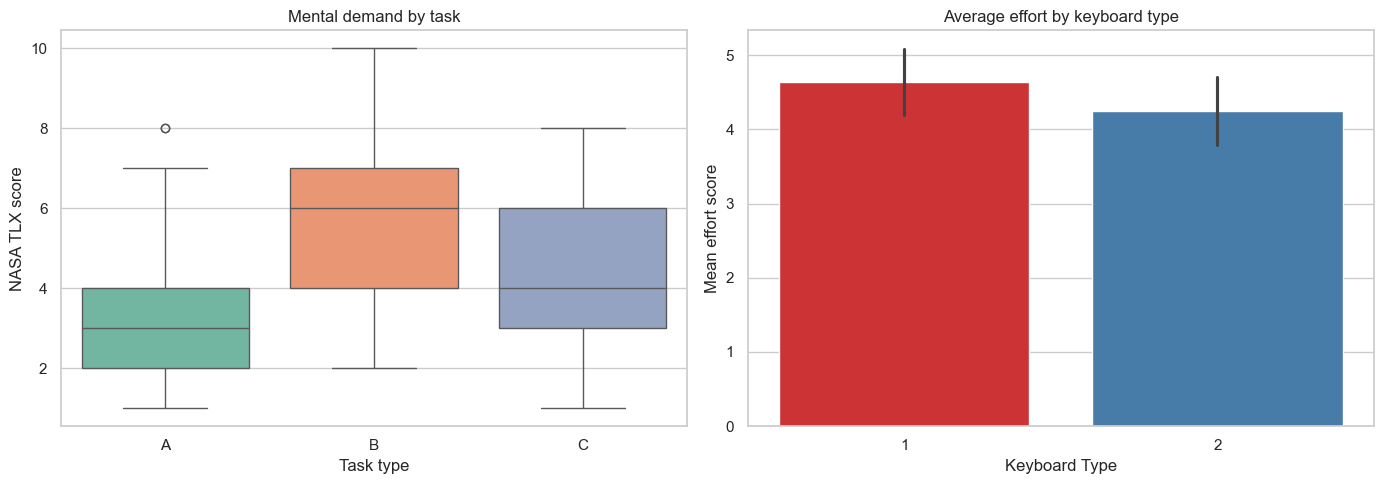

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=nasa_tlx_df, x="Task Type", y="Mental Demand", ax=axes[0], palette="Set2")
axes[0].set_title("Mental demand by task")
axes[0].set_xlabel("Task type")
axes[0].set_ylabel("NASA TLX score")

sns.barplot(
    data=nasa_tlx_df,
    x="Keyboard Type",
    y="Effort",
    estimator=np.mean,
    errorbar=("ci", 95),
    palette="Set1",
    ax=axes[1],
)
axes[1].set_title("Average effort by keyboard type")
axes[1].set_ylabel("Mean effort score")
plt.tight_layout()


#### NASA TLX dataset: correlation between workload dimensions


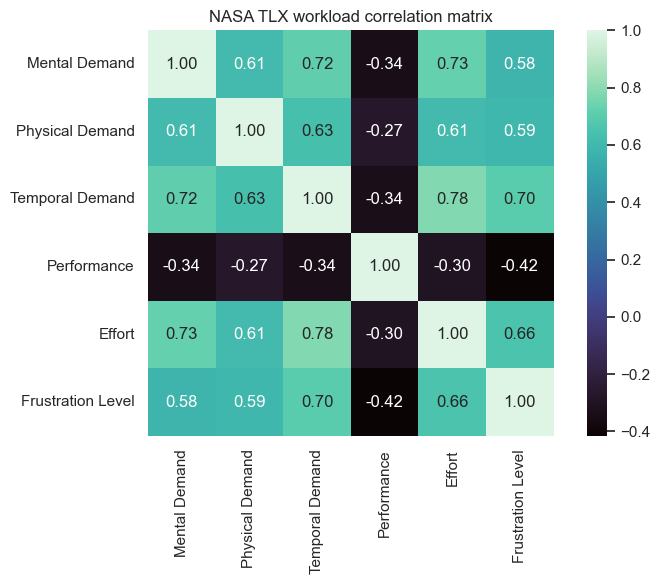

In [17]:
nasa_corr = nasa_tlx_df[workload_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(nasa_corr, cmap="mako", annot=True, fmt=".2f", square=True)
plt.title("NASA TLX workload correlation matrix")
plt.tight_layout()


### Quick takeaways
- Typing performance varies widely (Text_60_WPM ranges from the mid-30s to 100+ WPM) yet accuracies remain clustered above 80%. Higher WPM tasks (e.g., Text_100) introduce broader variance, especially for numerical/programming passages.
- Group-level summaries suggest Groups 3–4 generally have the fastest typing speeds in both 60 and 100 WPM tasks, whereas Groups 1–2 show more dispersion.
- Correlation analysis shows positive relationships between each mode's WPM and accuracy, indicating faster typists in this sample also tend to stay accurate; programming tasks at 100 WPM are the most weakly correlated with their 60 WPM counterparts, hinting at modality-specific skills.
- NASA TLX scores skew toward moderate workloads (means ~4–5), but Task Type B elicits noticeably higher mental demand and effort across keyboard types.
- Keyboard Type 2 scenarios trend toward higher effort/frustration than Type 1, and workload dimensions are strongly interrelated (e.g., effort/frustration correlation >0.8).


## Detailed Data Analysis

## TODO: Ensure that our findings are statistically significant? By doing p-test first...?

### Detailed relationships for keyboard-task combinations
We'll reshape both datasets so each row represents a `(participant, keyboard, task)` tuple. That lets us compare 60% vs 100% keyboards (KB1 vs KB2) for the three task types (Text, Number, Programming) in terms of typing performance and NASA-TLX workload, then look at how subjective workload aligns with measured performance.


In [39]:
task_meta = {
    "Text": {"code": "A", "label": "Task A · Text Entry"},
    "Num": {"code": "B", "label": "Task B · Number Entry"},
    "Prog": {"code": "C", "label": "Task C · Programming"},
}
keyboard_meta_perf = {"60": "KB1 (60%)", "100": "KB2 (100%)"}
perf_metrics = [
    "WPM",
    "Accuracy",
    "ErrorRate",
    "MouseTime",
    "Clicks",
    "Backspaces",
    "Scrolls",
    "TotalTime",
    "CorrectChars",
    "IncorrectFixed",
    "IncorrectNotFixed",
]

perf_long = []
for task_prefix, task_info in task_meta.items():
    for kb_suffix, kb_label in keyboard_meta_perf.items():
        col_map = {metric: f"{task_prefix}_{kb_suffix}_{metric}" for metric in perf_metrics}
        available_cols = [col for col in col_map.values() if col in typing_test_df.columns]
        if len(available_cols) != len(perf_metrics):
            missing = sorted(set(col_map.values()) - set(available_cols))
            raise ValueError(f"Missing columns for {task_prefix} {kb_suffix}: {missing}")

        subset = typing_test_df[["Participant Number", "GroupNumber"] + available_cols].copy()
        subset = subset.rename(columns={v: k for k, v in col_map.items()})
        subset["Keyboard"] = kb_label
        subset["Task"] = task_info["label"]
        subset["TaskCode"] = task_info["code"]
        perf_long.append(subset)

perf_long = pd.concat(perf_long, ignore_index=True)
perf_long.head()

,Participant Number,GroupNumber,WPM,Accuracy,ErrorRate,MouseTime,Clicks,Backspaces,Scrolls,TotalTime,CorrectChars,IncorrectFixed,IncorrectNotFixed,Keyboard,Task,TaskCode
0,2,2,89.0,92.4,7.6,0.045,0,25,0,40.982,304,25,0,KB1 (60%),Task A · Text Entry,A
1,3,3,73.7,84.9,15.1,0.000,0,54,0,49.531,304,54,0,KB1 (60%),Task A · Text Entry,A
2,4,4,61.7,89.6,10.4,0.000,0,40,0,67.079,345,40,0,KB1 (60%),Task A · Text Entry,A
3,5,5,68.8,93.5,6.5,0.000,0,24,0,60.183,345,24,0,KB1 (60%),Task A · Text Entry,A
4,12,6,53.1,93.8,6.2,0.000,0,23,0,77.976,345,23,0,KB1 (60%),Task A · Text Entry,A


In [40]:
numeric_cols = perf_metrics
perf_long[numeric_cols] = perf_long[numeric_cols].apply(pd.to_numeric, errors="coerce")

perf_summary = (
    perf_long.groupby(["Keyboard", "Task"])[["WPM", "Accuracy", "ErrorRate", "TotalTime"]]
    .agg(["mean", "std"])
    .round(2)
)
perf_summary


WPM        Accuracy        ErrorRate  \
                                   mean    std     mean    std      mean   
Keyboard   Task                                                            
KB1 (60%)  Task A · Text Entry    69.28  18.64    92.28   3.52      7.80   
           Task B · Number Entry  29.19   8.99    85.94  10.08     13.22   
           Task C · Programming   38.38  12.65    87.87  13.73     10.05   
KB2 (100%) Task A · Text Entry    70.31  19.48    90.99   4.69      8.39   
           Task B · Number Entry  29.54   7.74    85.10   4.68     14.12   
           Task C · Programming   37.38  11.93    86.80   7.95     11.34   

                                       TotalTime         
                                   std      mean    std  
Keyboard   Task                                          
KB1 (60%)  Task A · Text Entry    3.96     60.86  19.69  
           Task B · Number Entry  6.09    111.66  12.78  
           Task C · Programming   4.60     95.11  21.93  
KB2 (100%) Task A · Text Entry    4.53     60.22  20.86  
           Task B · Number Entry  4.76    112.30  12.55  
           Task C · Programming   4.31     97.96  20.36

Difference in Mean WPM for KB1 versus KB2. 

In [41]:
# TODO: Add more analysis here.
wpm_pivot = perf_long.groupby(["Task", "Keyboard"])['WPM'].mean().unstack()
wpm_pivot['Difference from KB2-KB1'] = wpm_pivot['KB2 (100%)'] - wpm_pivot['KB1 (60%)']
wpm_pivot.round(2)

Keyboard,KB1 (60%),KB2 (100%),Difference from KB2-KB1
Task,,,
Task A · Text Entry,69.28,70.31,1.03
Task B · Number Entry,29.19,29.54,0.35
Task C · Programming,38.38,37.38,-0.99


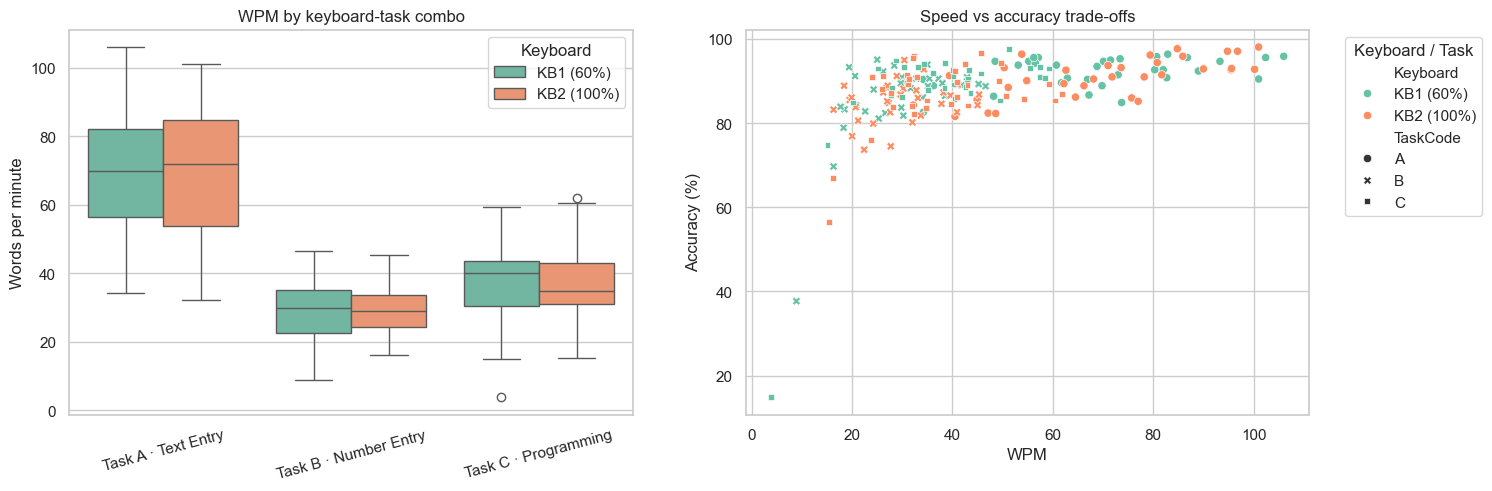

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(
    data=perf_long,
    x="Task",
    y="WPM",
    hue="Keyboard",
    palette="Set2",
    ax=axes[0],
)
axes[0].set_title("WPM by keyboard-task combo")
axes[0].set_xlabel("")
axes[0].set_ylabel("Words per minute")
axes[0].tick_params(axis='x', rotation=15)

sns.scatterplot(
    data=perf_long,
    x="WPM",
    y="Accuracy",
    hue="Keyboard",
    style="TaskCode",
    palette="Set2",
    ax=axes[1],
)
axes[1].set_title("Speed vs accuracy trade-offs")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(title="Keyboard / Task", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

In [43]:
keyboard_meta_tlx = {1: "KB1 (60%)", 2: "KB2 (100%)"}
task_label_map = {meta["code"]: meta["label"] for meta in task_meta.values()}

nasa_aug = nasa_tlx_df.copy()
nasa_aug["Keyboard"] = nasa_aug["Keyboard Type"].map(keyboard_meta_tlx)
nasa_aug["Task"] = nasa_aug["Task Type"].map(task_label_map)
nasa_aug["Overall Score"] = nasa_aug[workload_cols].mean(axis=1)

nasa_summary = (
    nasa_aug.groupby(["Keyboard", "Task"])[["Overall Score"] + workload_cols]
    .agg(["mean", "std"])
    .round(2)
)
nasa_summary


Overall Score       Mental Demand        \
                                          mean   std          mean   std   
Keyboard   Task                                                            
KB1 (60%)  Task A · Text Entry            3.95  1.32          3.42  1.92   
           Task B · Number Entry          5.25  1.57          5.73  2.07   
           Task C · Programming           4.58  1.32          4.27  1.61   
KB2 (100%) Task A · Text Entry            3.75  1.24          3.00  1.62   
           Task B · Number Entry          5.24  1.48          5.52  1.95   
           Task C · Programming           4.31  1.43          3.97  1.93   

                                 Physical Demand       Temporal Demand        \
                                            mean   std            mean   std   
Keyboard   Task                                                                
KB1 (60%)  Task A · Text Entry              3.12  1.65            3.24  2.24   
           Task B · Number Entry            4.76  2.25            5.24  2.70   
           Task C · Programming             4.33  2.20            4.06  2.08   
KB2 (100%) Task A · Text Entry              2.97  1.67            3.21  2.03   
           Task B · Number Entry            4.91  2.35            5.48  2.29   
           Task C · Programming             3.73  2.10            3.82  2.17   

                                 Performance       Effort        \
                                        mean   std   mean   std   
Keyboard   Task                                                   
KB1 (60%)  Task A · Text Entry          7.88  2.04   3.67  2.20   
           Task B · Number Entry        5.42  2.08   5.73  2.34   
           Task C · Programming         7.12  2.06   4.52  2.03   
KB2 (100%) Task A · Text Entry          7.88  1.98   3.18  1.91   
           Task B · Number Entry        5.79  1.92   5.58  2.03   
           Task C · Programming         7.03  2.21   4.00  2.09   

                                 Frustration Level        
                                              mean   std  
Keyboard   Task                                           
KB1 (60%)  Task A · Text Entry                2.36  1.76  
           Task B · Number Entry              4.64  2.86  
           Task C · Programming               3.18  1.74  
KB2 (100%) Task A · Text Entry                2.24  1.66  
           Task B · Number Entry              4.18  2.30  
           Task C · Programming               3.33  2.39

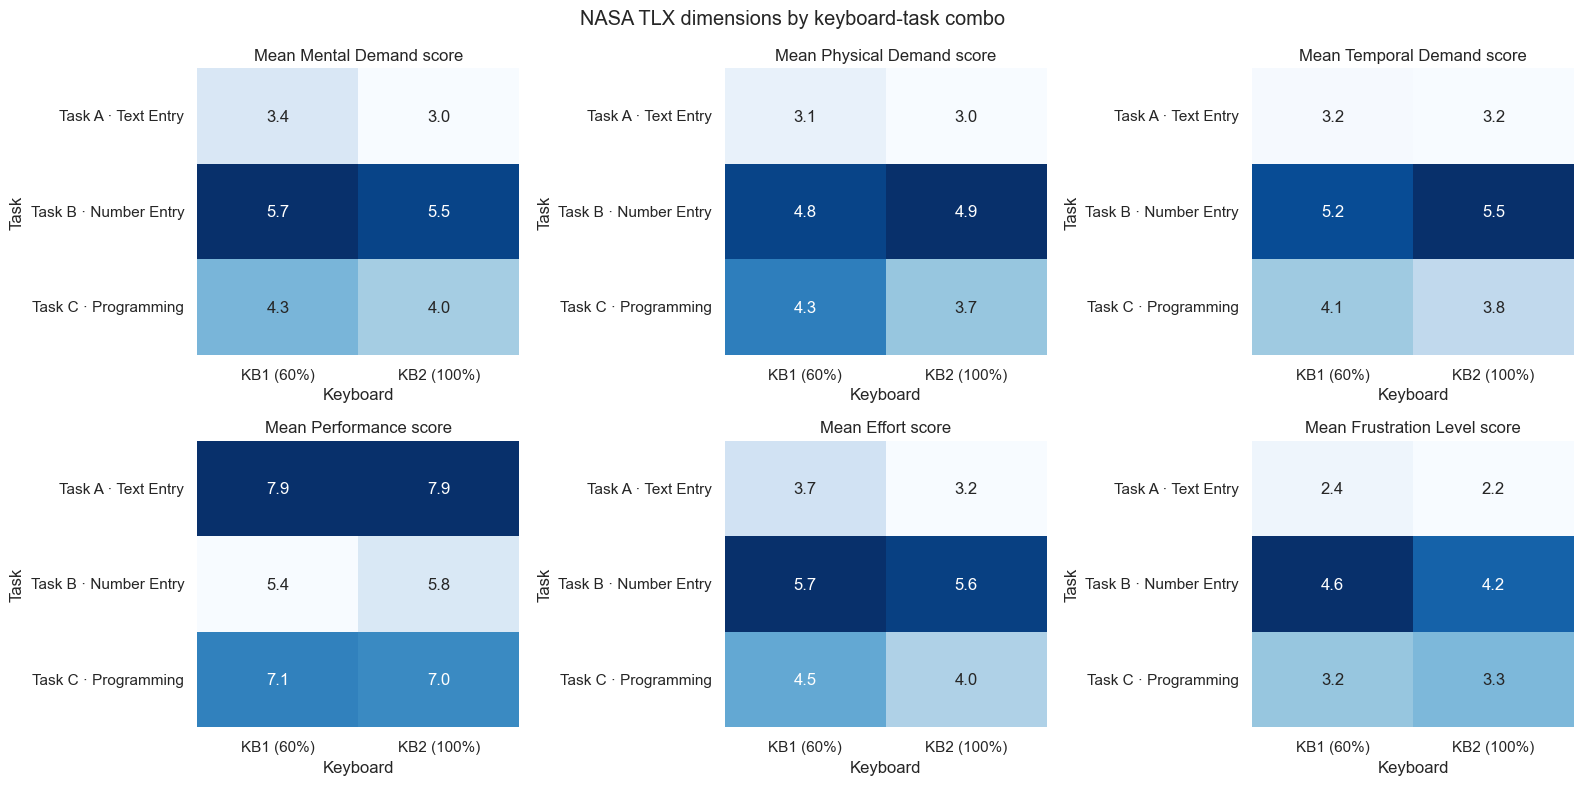

Keyboard,KB1 (60%),KB2 (100%)
Task,,
Task A · Text Entry,3.95,3.75
Task B · Number Entry,5.25,5.24
Task C · Programming,4.58,4.31


In [36]:
overall_pivot = nasa_aug.pivot_table(
    index="Task",
    columns="Keyboard",
    values="Overall Score",
    aggfunc="mean",
).round(2)

dimension_pivots = {
    dim: nasa_aug.pivot_table(index="Task", columns="Keyboard", values=dim, aggfunc="mean").round(2)
    for dim in workload_cols
}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, (dim, pivot) in zip(axes.ravel(), dimension_pivots.items()):
    sns.heatmap(pivot, annot=True, cmap="Blues", fmt=".1f", ax=ax, cbar=False)
    ax.set_title(f"Mean {dim} score")
    ax.set_xlabel("Keyboard")
    ax.set_ylabel("Task")
plt.suptitle("NASA TLX dimensions by keyboard-task combo")
plt.tight_layout()
plt.show()

overall_pivot


**NASA TLX dimension highlights**
- Mental and Temporal Demand spike on Task B regardless of keyboard, while Physical Demand increases noticeably for KB2 during Task C.
- Effort and Frustration are consistently higher on KB2 for Tasks B/C, hinting that the larger layout may slow precision-heavy work.
- Performance ratings (where higher is better) dip most for KB1 on Task B, suggesting the smaller layout may feel less effective when entering numbers.


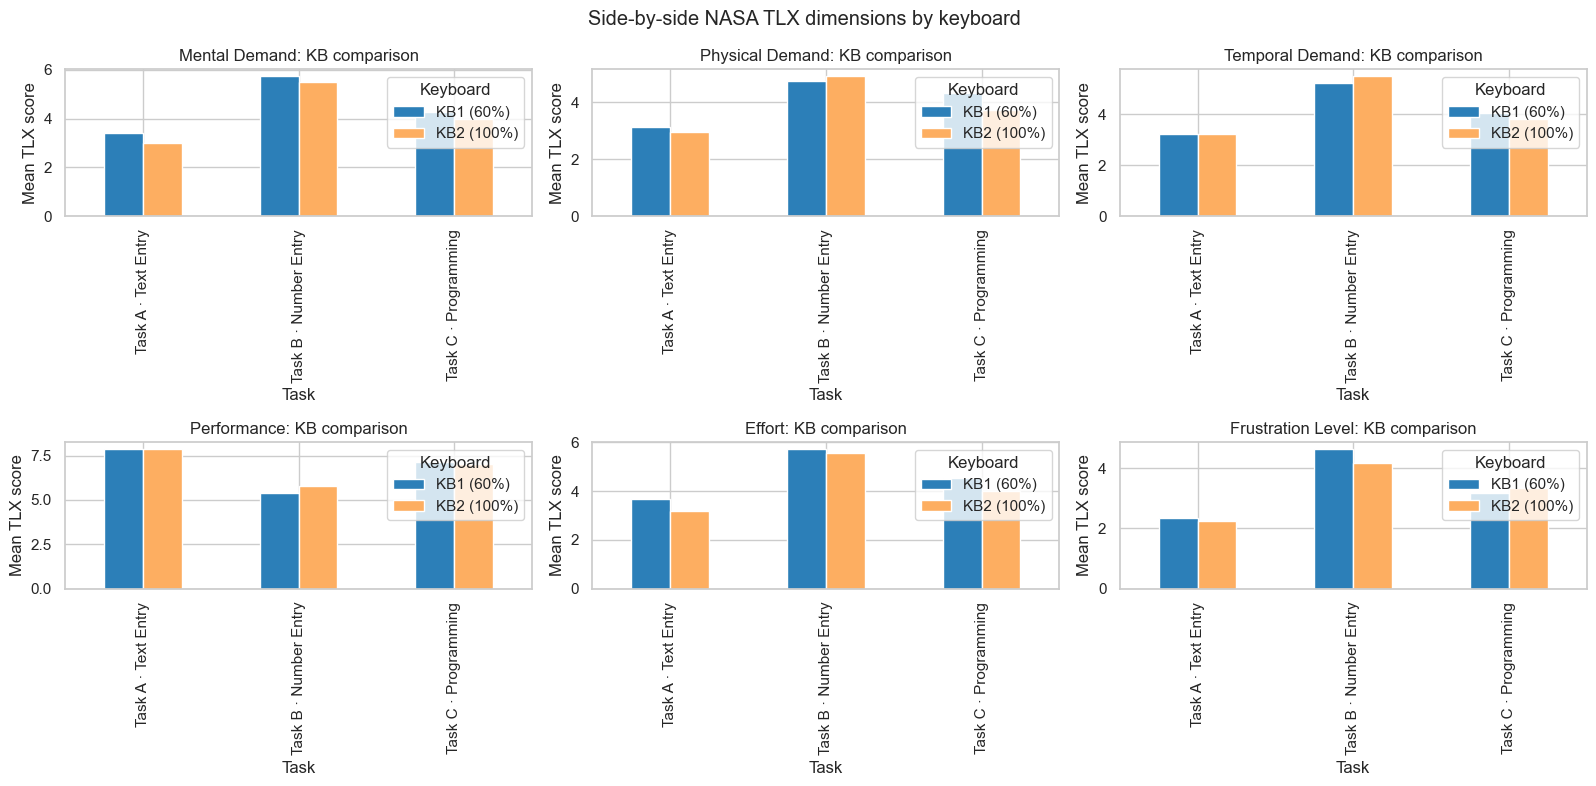

In [44]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
colors = ["#2c7fb8", "#fdae61"]
for ax, (dim, pivot) in zip(axes.ravel(), dimension_pivots.items()):
    pivot.plot(kind="bar", stacked=False, ax=ax, color=colors)
    ax.set_title(f"{dim}: KB comparison")
    ax.set_ylabel("Mean TLX score")
    ax.set_xlabel("Task")
    ax.legend(title="Keyboard", loc="upper right")
plt.suptitle("Side-by-side NASA TLX dimensions by keyboard")
plt.tight_layout()
plt.show()


In [48]:
perf_tlx = perf_long.merge(
    nasa_aug[["Participant Number", "Keyboard", "Task", "Overall Score"] + workload_cols],
    on=["Participant Number", "Keyboard", "Task"],
    how="inner",
)

corr_with_tlx = perf_tlx[["WPM", "Accuracy", "ErrorRate", "Overall Score"]].corr().loc["Overall Score"].round(2)
corr_with_tlx


WPM             -0.44
Accuracy        -0.34
ErrorRate        0.39
Overall Score    1.00
Name: Overall Score, dtype: float64

The graph below shows that higher WPM seems to correlate to lower perceived workload. This could be because people who type faster perceive the task to also be easier.

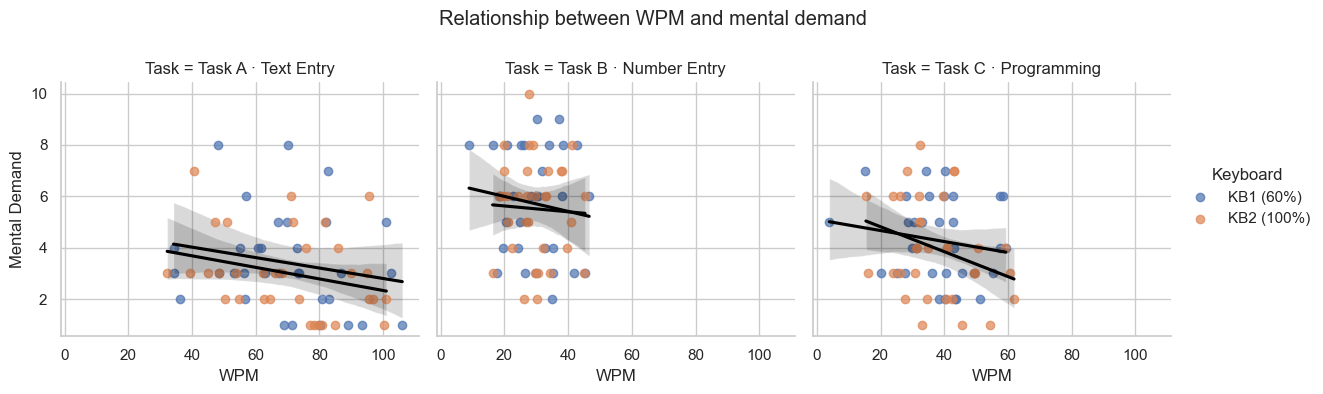

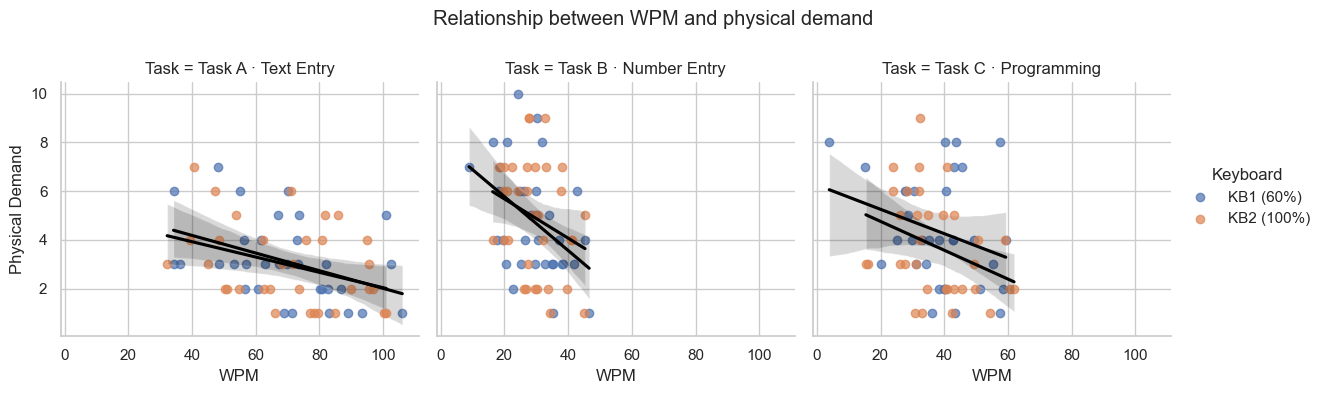

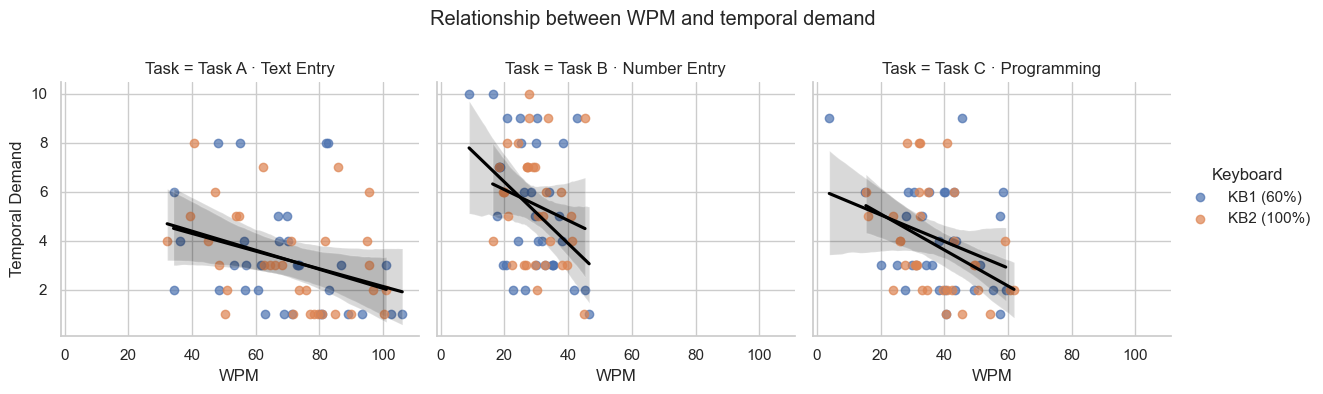

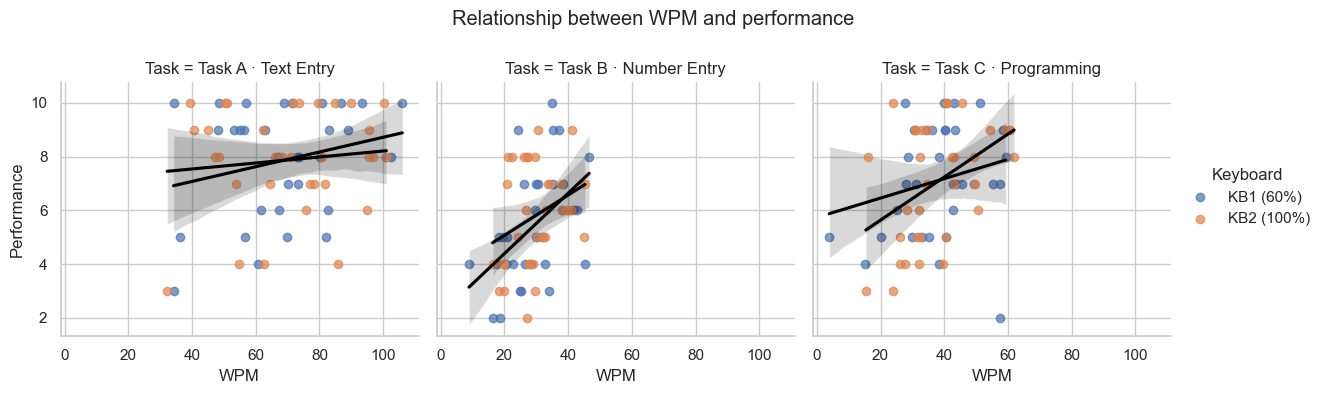

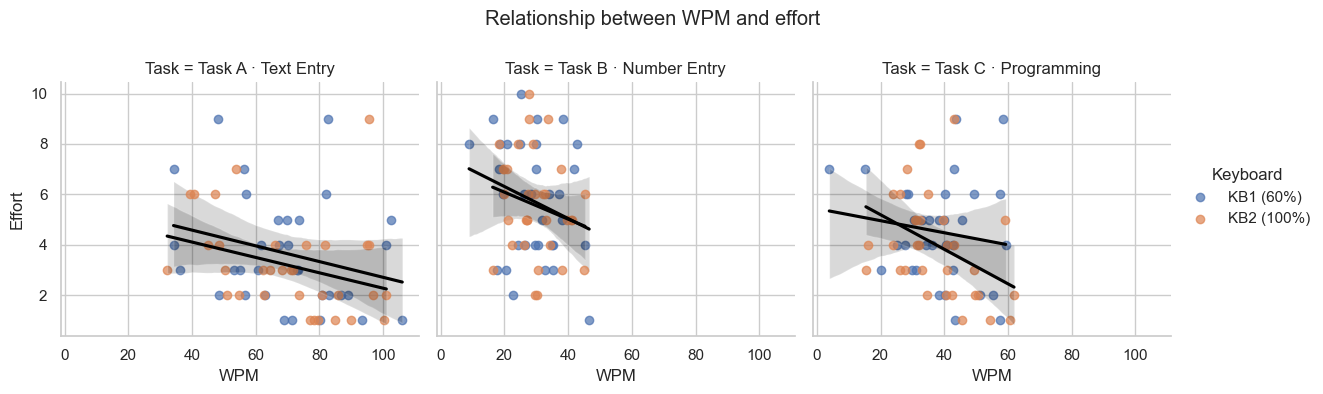

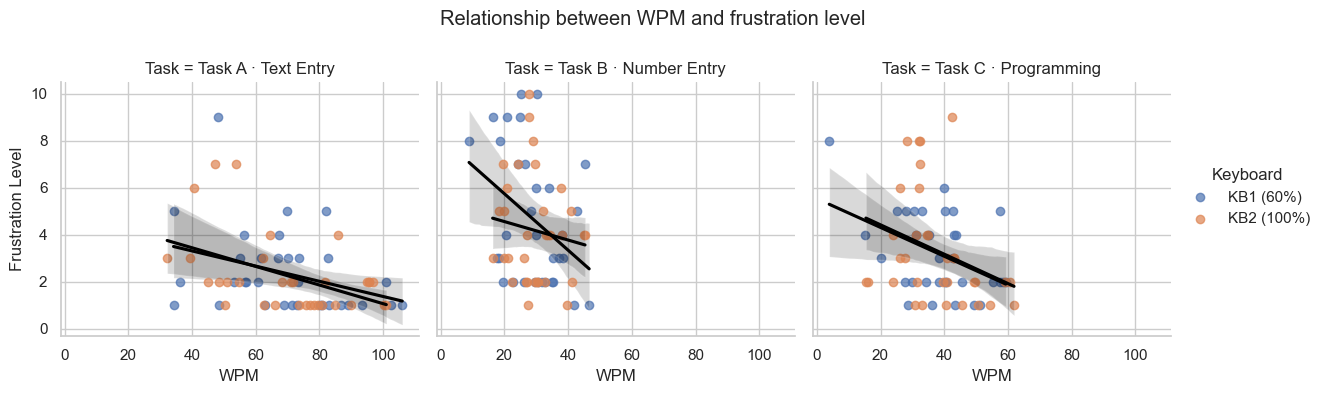

In [53]:
x = "WPM"
for dim in workload_cols:
    g = sns.lmplot(
        data=perf_tlx,
        x=x,
        y=dim,
        hue="Keyboard",
        col="Task",
        height=4,
        aspect=1,
        scatter_kws={"alpha": 0.7},
        line_kws={"color": "black"},
    )
    g.figure.subplots_adjust(top=0.8)
    g.figure.suptitle(f"Relationship between {x} and {dim.lower()}")
    plt.show()


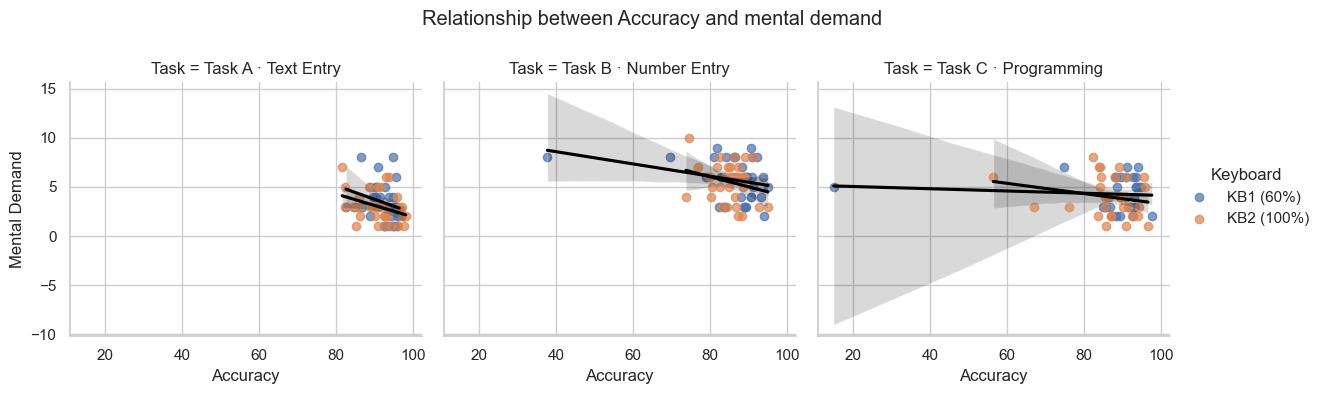

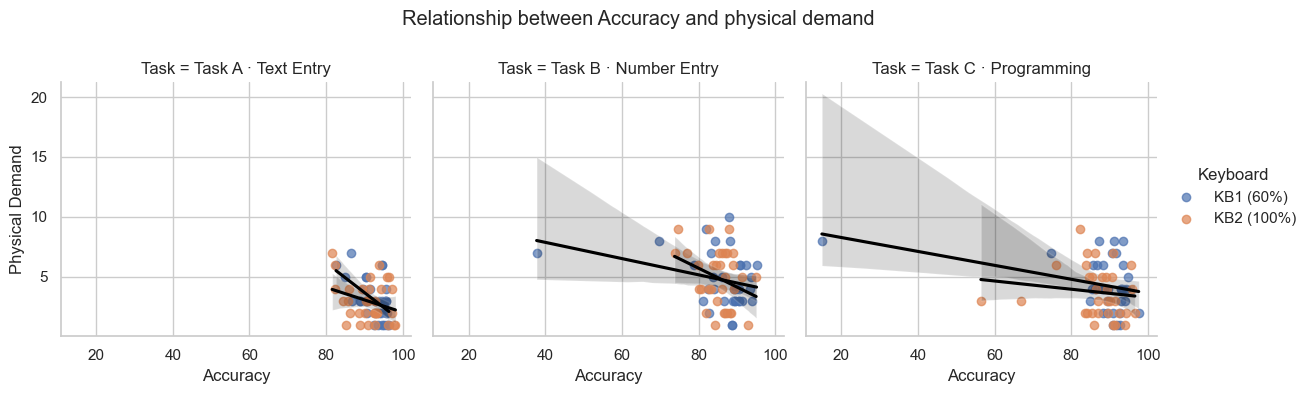

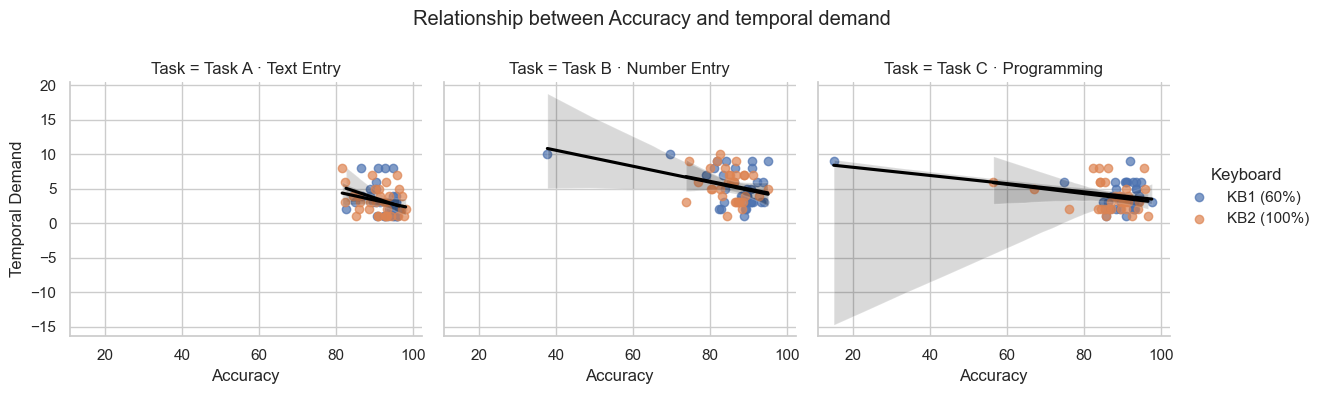

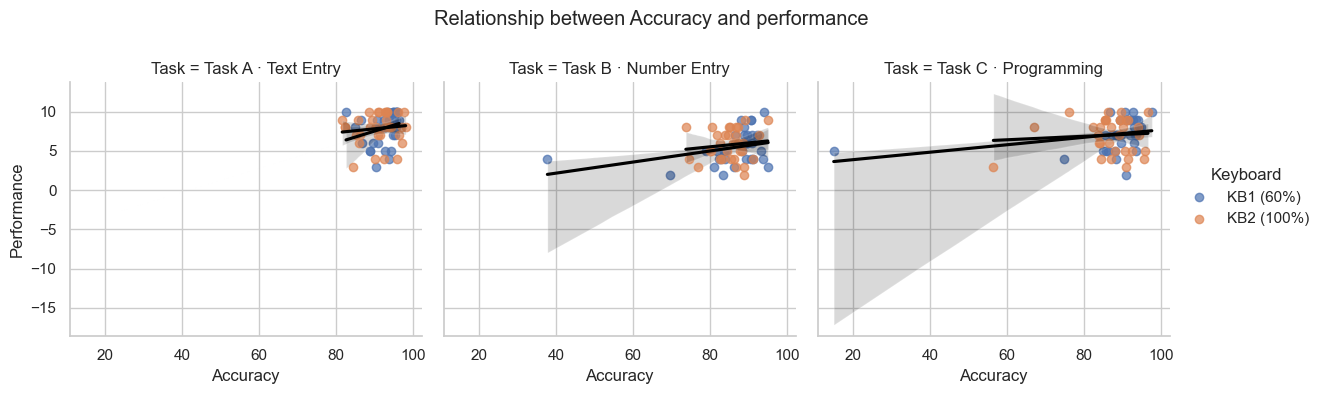

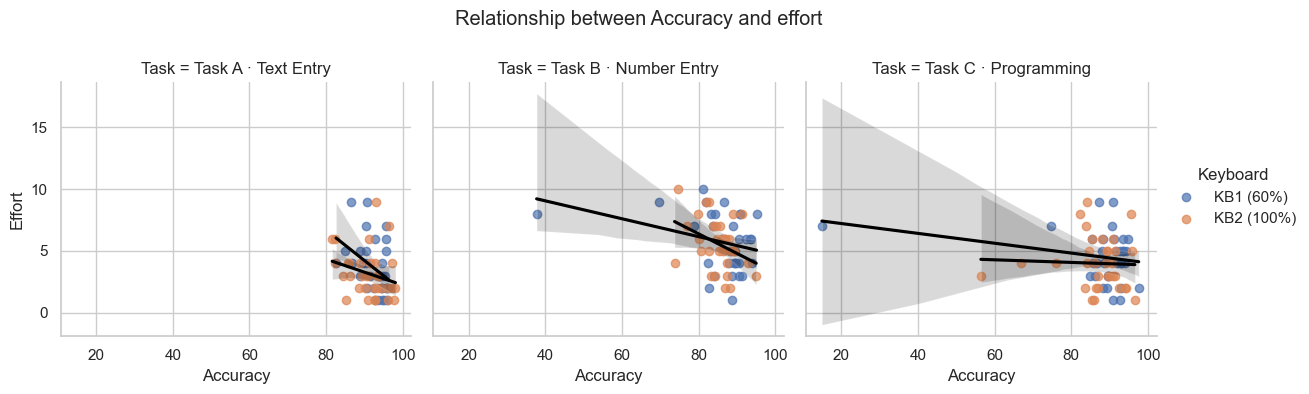

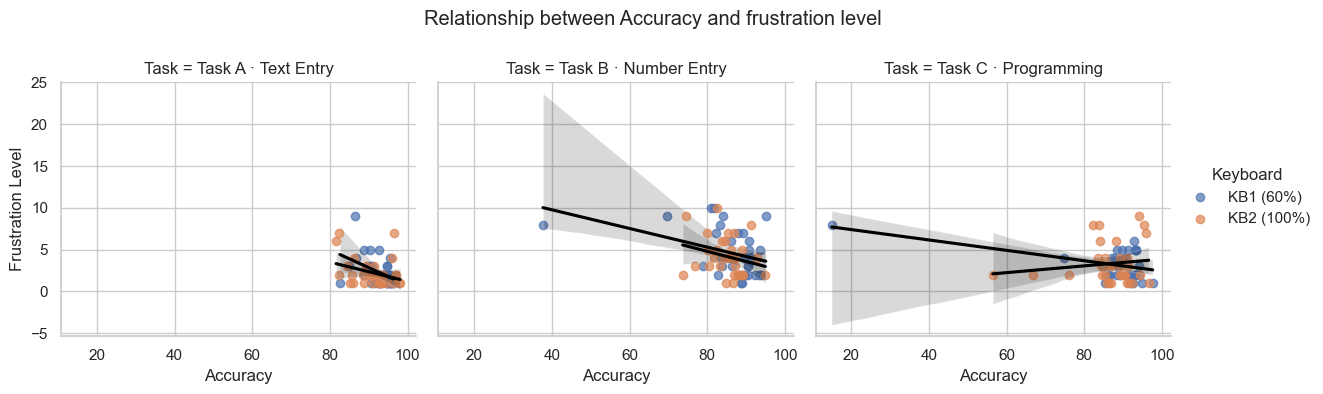

In [54]:
x = "Accuracy"
for dim in workload_cols:
    g = sns.lmplot(
        data=perf_tlx,
        x=x,
        y=dim,
        hue="Keyboard",
        col="Task",
        height=4,
        aspect=1,
        scatter_kws={"alpha": 0.7},
        line_kws={"color": "black"},
    )
    g.figure.subplots_adjust(top=0.8)
    g.figure.suptitle(f"Relationship between {x} and {dim.lower()}")
    plt.show()


## TODO: Double check this...
**Key insights**
- Typing speed gaps between keyboards are small (≤1 WPM on average) across all tasks; Text Entry favors KB2 slightly (+1 WPM) while Programming shows a modest KB1 edge (−1 WPM for KB2). Accuracy follows the same minor shifts, reinforcing that keyboard choice alone is not a dominant driver of raw performance.
- Task B · Number Entry is the clear bottleneck regardless of keyboard (≈29 WPM vs 69 WPM on Task A), mirroring the highest error rates (~14%) and the longest completion times (~112 s). Task design, not keyboard size, explains most of the variance.
- NASA TLX composites are consistently highest for Task B (~5.25) and lowest for Task A (~3.8–4.0). KB2 trims perceived workload slightly for the more demanding Programming task (4.31 vs 4.58) but has almost no effect on Number Entry.
- When we merge objective speed with subjective workload, faster typists report lower TLX scores (WPM vs TLX r = −0.44), while error-prone runs align with higher workload (ErrorRate vs TLX r = +0.39). This suggests UX gains may come more from helping participants maintain accuracy than from swapping keyboard form factors.
